## Phase 6 — Machine Learning Models

Using the cleaned financial dataset to build and compare three 
classification models that predict whether a movie will be a 
financial flop or success.

Additionally a regression model predicts exact revenue figures.

Models built:
1. Logistic Regression (baseline classifier)
2. Decision Tree (interpretable classifier)
3. Random Forest (main classifier)
4. Linear Regression (baseline regressor)
5. Random Forest Regressor (main regressor)

Target variables:
- Classification: was_flop (True/False)
- Regression: revenue ($)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             classification_report, 
                             mean_absolute_error, r2_score)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Load financial subset — already budget filtered
df = pd.read_csv('data/netflix_financial_clean.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFlop rate: {df['was_flop'].mean()*100:.1f}%")

Dataset shape: (3525, 22)

Columns: ['title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'genres', 'language', 'popularity', 'vote_count', 'vote_average', 'budget', 'revenue', 'rating_tier', 'year_added', 'month_added', 'movie_age', 'profit', 'roi_pct', 'was_flop', 'budget_tier']

Flop rate: 36.7%


### Feature Preparation

ML models require numeric inputs only. We need to:
1. Select relevant features
2. Encode categorical columns (genre, language) to numbers
3. Handle any remaining issues
4. Split into train and test sets

In [9]:
# Select features that logically influence flop/success
# Exclude columns that are outcomes themselves (revenue, profit, roi_pct)
features = ['budget', 'popularity', 'release_year', 
            'vote_count', 'language', 'genres']

target_class = 'was_flop'
target_reg = 'revenue'

# Work on a copy
ml_df = df[features + [target_class, target_reg]].copy()

print(f"Starting rows: {len(ml_df)}")

# Drop any rows with nulls in selected features
ml_df = ml_df.dropna(subset=features + [target_class])
print(f"After dropping nulls: {len(ml_df)}")

# Simplify genres — take only the first genre listed
# "Action, Adventure, Comedy" → "Action"
ml_df['primary_genre'] = ml_df['genres'].str.split(',').str[0].str.strip()

# Encode language — top 5 languages get own category, rest = 'other'
top_languages = ml_df['language'].value_counts().head(5).index.tolist()
ml_df['language_encoded'] = ml_df['language'].apply(
    lambda x: x if x in top_languages else 'other'
)

# Label encode categorical columns
le_genre = LabelEncoder()
le_language = LabelEncoder()

ml_df['genre_encoded'] = le_genre.fit_transform(ml_df['primary_genre'])
ml_df['language_encoded'] = le_language.fit_transform(ml_df['language_encoded'])

# Final feature set — all numeric now
feature_cols = ['budget', 'popularity', 'release_year', 
                'vote_count', 'genre_encoded', 'language_encoded']

print(f"\nFeature columns: {feature_cols}")
print(f"\nGenre encoding sample:")
for genre, code in zip(le_genre.classes_, range(len(le_genre.classes_))):
    print(f"  {code} = {genre}")

Starting rows: 3525
After dropping nulls: 3525

Feature columns: ['budget', 'popularity', 'release_year', 'vote_count', 'genre_encoded', 'language_encoded']

Genre encoding sample:
  0 = Action
  1 = Adventure
  2 = Animation
  3 = Comedy
  4 = Crime
  5 = Documentary
  6 = Drama
  7 = Family
  8 = Fantasy
  9 = History
  10 = Horror
  11 = Music
  12 = Mystery
  13 = Romance
  14 = Science Fiction
  15 = Thriller
  16 = War
  17 = Western


In [10]:
X = ml_df[feature_cols]
y_class = ml_df[target_class].astype(int)  # True/False to 1/0
y_reg = ml_df[target_reg]

# 80% training, 20% testing
# random_state=42 means results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} movies")
print(f"Testing set:  {X_test.shape[0]} movies")
print(f"\nFlop rate in training: {y_train.mean()*100:.1f}%")
print(f"Flop rate in testing:  {y_test.mean()*100:.1f}%")

Training set: 2820 movies
Testing set:  705 movies

Flop rate in training: 36.2%
Flop rate in testing:  38.9%


### Classification — Predicting Flop vs Success

Three models trained and compared. Each evaluated on the same 
test set of movies the model has never seen during training.

In [11]:
# Model 1 — Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# Model 2 — Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

# Model 3 — Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("=== CLASSIFICATION RESULTS ===")
print(f"Logistic Regression: {lr_acc*100:.1f}%")
print(f"Decision Tree:       {dt_acc*100:.1f}%")
print(f"Random Forest:       {rf_acc*100:.1f}%")

=== CLASSIFICATION RESULTS ===
Logistic Regression: 71.3%
Decision Tree:       72.8%
Random Forest:       73.3%


=== RANDOM FOREST — DETAILED REPORT ===
              precision    recall  f1-score   support

     Success       0.75      0.84      0.79       431
        Flop       0.69      0.57      0.62       274

    accuracy                           0.73       705
   macro avg       0.72      0.70      0.71       705
weighted avg       0.73      0.73      0.73       705


=== CONFUSION MATRIX ===
[[362  69]
 [119 155]]


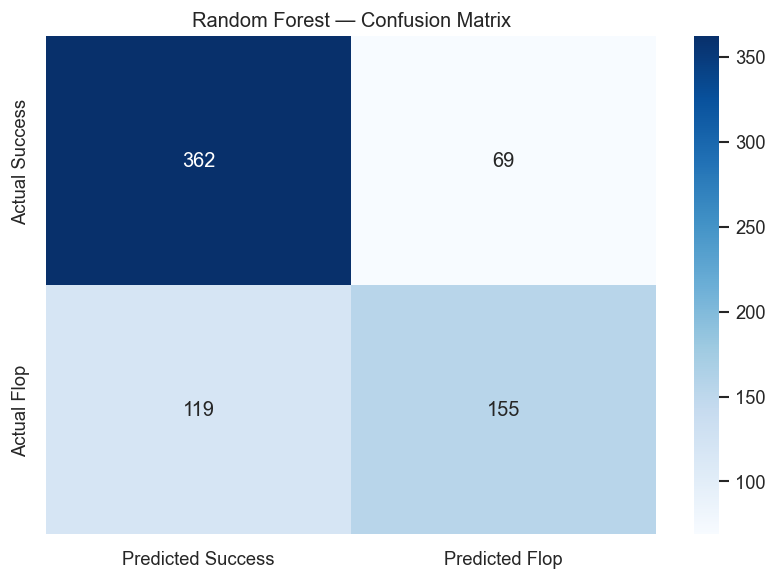

In [12]:
print("=== RANDOM FOREST — DETAILED REPORT ===")
print(classification_report(y_test, rf_pred, 
      target_names=['Success', 'Flop']))

print("\n=== CONFUSION MATRIX ===")
cm = confusion_matrix(y_test, rf_pred)
print(cm)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Success', 'Predicted Flop'],
            yticklabels=['Actual Success', 'Actual Flop'])
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.savefig('charts/ml_confusion_matrix.png', bbox_inches='tight')
plt.show()

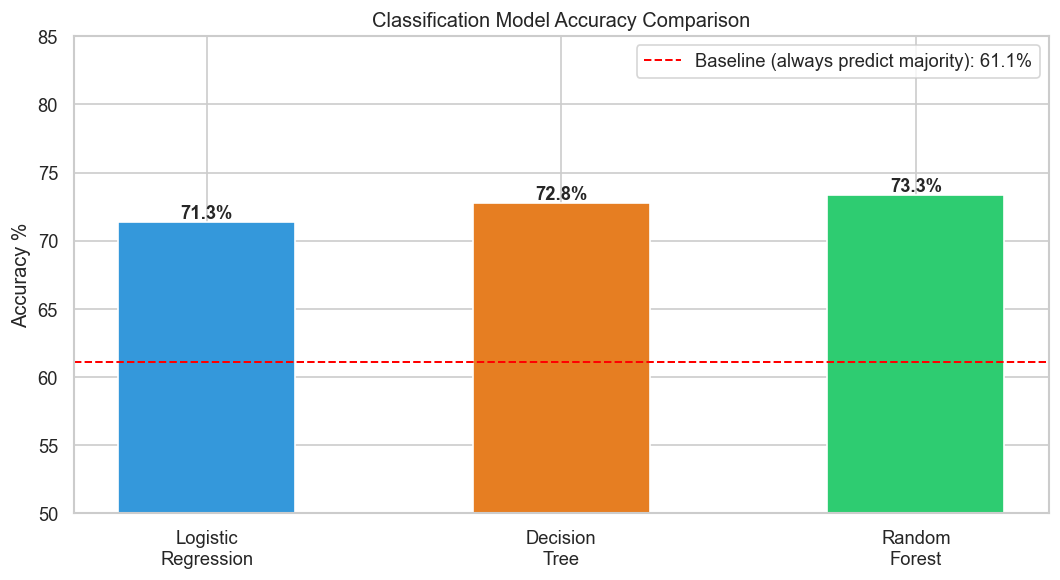

In [13]:
models = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest']
accuracies = [lr_acc*100, dt_acc*100, rf_acc*100]
colors = ['#3498db', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(models, accuracies, color=colors, width=0.5)
ax.set_ylim(50, 85)
ax.set_title('Classification Model Accuracy Comparison')
ax.set_ylabel('Accuracy %')
ax.axhline(y=100*(1-y_test.mean()), color='red', 
           linestyle='--', linewidth=1.2,
           label=f'Baseline (always predict majority): {100*(1-y_test.mean()):.1f}%')
ax.legend()

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/ml_model_comparison.png', bbox_inches='tight')
plt.show()

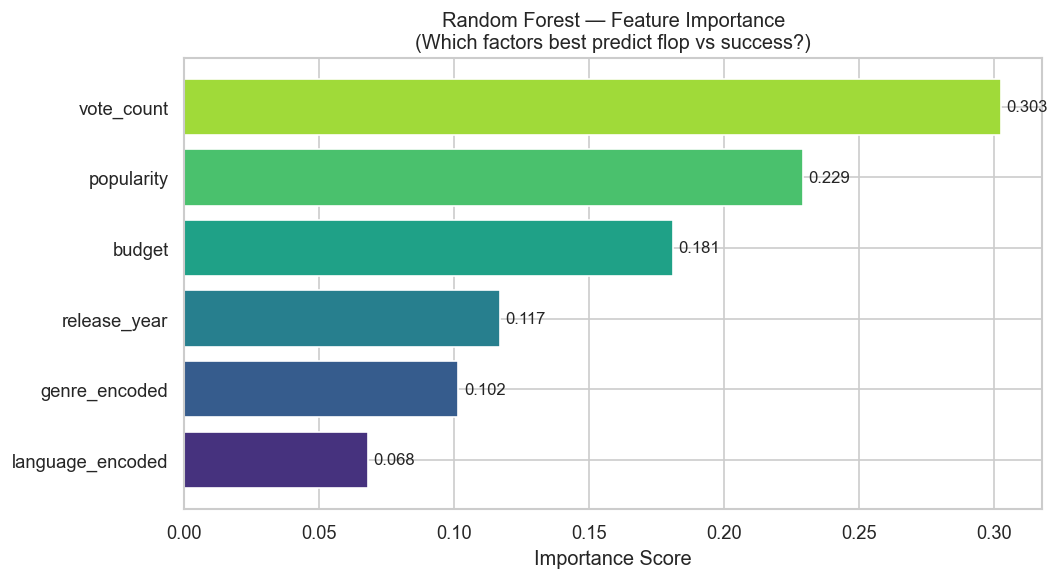

In [14]:
# Feature importance from Random Forest
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importance_df['feature'], 
               importance_df['importance'],
               color=sns.color_palette('viridis', len(feature_cols)))
ax.set_title('Random Forest — Feature Importance\n(Which factors best predict flop vs success?)')
ax.set_xlabel('Importance Score')

for bar, val in zip(bars, importance_df['importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('charts/ml_feature_importance.png', bbox_inches='tight')
plt.show()

### Regression — Predicting Movie Revenue

Instead of flop/success we now predict the actual revenue figure 
in dollars. This answers "how much will this movie make" rather 
than just "will it lose money."

Evaluated using:
- MAE (Mean Absolute Error) — average dollar prediction error
- R² Score — how much variance the model explains (0 to 1)

In [15]:
# Model 1 — Linear Regression baseline
lin_reg = LinearRegression()
lin_reg.fit(X_train_r, y_train_r)
lin_pred = lin_reg.predict(X_test_r)

lin_mae = mean_absolute_error(y_test_r, lin_pred)
lin_r2 = r2_score(y_test_r, lin_pred)

# Model 2 — Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_r, y_train_r)
rf_reg_pred = rf_reg.predict(X_test_r)

rf_mae = mean_absolute_error(y_test_r, rf_reg_pred)
rf_r2 = r2_score(y_test_r, rf_reg_pred)

print("=== REGRESSION RESULTS ===")
print(f"\nLinear Regression:")
print(f"  MAE: ${lin_mae:,.0f}")
print(f"  R²:  {lin_r2:.3f}")

print(f"\nRandom Forest Regressor:")
print(f"  MAE: ${rf_mae:,.0f}")
print(f"  R²:  {rf_r2:.3f}")

=== REGRESSION RESULTS ===

Linear Regression:
  MAE: $61,991,475
  R²:  0.644

Random Forest Regressor:
  MAE: $49,802,370
  R²:  0.719


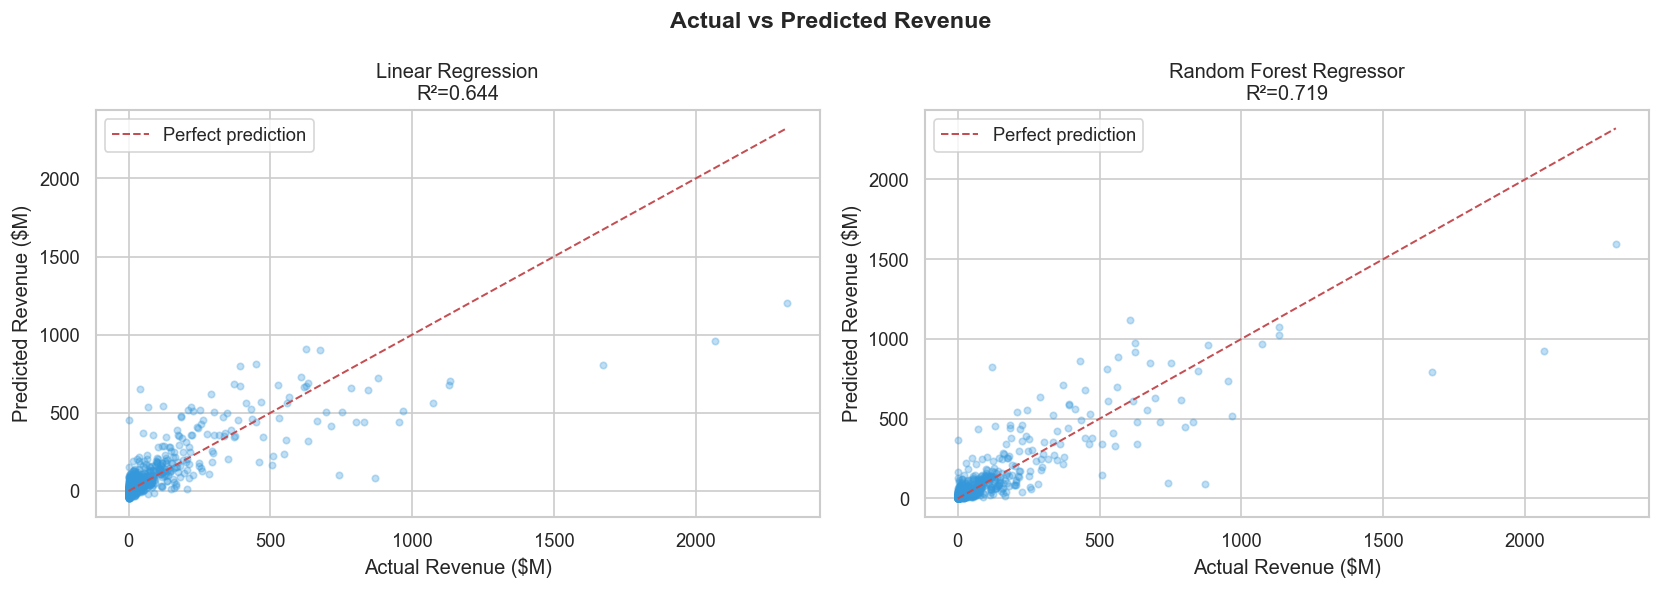

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(
    axes,
    [lin_pred, rf_reg_pred],
    ['Linear Regression', 'Random Forest Regressor']
):
    ax.scatter(y_test_r / 1_000_000, preds / 1_000_000,
               alpha=0.3, s=15, color='#3498db')
    max_val = max(y_test_r.max(), max(preds)) / 1_000_000
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.2,
            label='Perfect prediction')
    ax.set_title(f'{title}\nR²={r2_score(y_test_r, preds):.3f}')
    ax.set_xlabel('Actual Revenue ($M)')
    ax.set_ylabel('Predicted Revenue ($M)')
    ax.legend()

plt.suptitle('Actual vs Predicted Revenue', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/ml_regression_comparison.png', bbox_inches='tight')
plt.show()

In [19]:
# Retrain without vote_count — pure pre-release prediction model
feature_cols_v2 = ['budget', 'popularity', 'release_year',
                   'genre_encoded', 'language_encoded']

X_v2 = ml_df[feature_cols_v2]

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_class, test_size=0.2, random_state=42
)

X_train_r2, X_test_r2, y_train_r2, y_test_r2 = train_test_split(
    X_v2, y_reg, test_size=0.2, random_state=42
)

# Retrain all models
lr_v2 = LogisticRegression(max_iter=1000, random_state=42)
lr_v2.fit(X_train_v2, y_train_v2)

dt_v2 = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_v2.fit(X_train_v2, y_train_v2)

rf_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_v2.fit(X_train_v2, y_train_v2)

rf_reg_v2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_v2.fit(X_train_r2, y_train_r2)

# Compare accuracy
print("=== V2 MODEL ACCURACY (without vote_count) ===")
print(f"Logistic Regression: {accuracy_score(y_test_v2, lr_v2.predict(X_test_v2))*100:.1f}%")
print(f"Decision Tree:       {accuracy_score(y_test_v2, dt_v2.predict(X_test_v2))*100:.1f}%")
print(f"Random Forest:       {accuracy_score(y_test_v2, rf_v2.predict(X_test_v2))*100:.1f}%")

# Updated prediction function using v2 models
def predict_movie_v2(budget, genre, language, 
                     popularity=15, release_year=2024):
    
    if genre in le_genre.classes_:
        genre_code = le_genre.transform([genre])[0]
    else:
        genre_code = le_genre.transform(['Drama'])[0]
    
    lang = language if language in top_languages else 'other'
    lang_code = le_language.transform([lang])[0]
    
    features = pd.DataFrame(
        [[budget, popularity, release_year, genre_code, lang_code]],
        columns=feature_cols_v2
    )
    
    flop_prob = rf_v2.predict_proba(features)[0][1]
    success_prob = rf_v2.predict_proba(features)[0][0]
    prediction = "FLOP" if flop_prob > 0.5 else "SUCCESS"
    predicted_revenue = rf_reg_v2.predict(features)[0]
    predicted_profit = predicted_revenue - budget
    
    print(f"=== MOVIE PREDICTION (Pre-Release Model) ===")
    print(f"Budget:    ${budget:,.0f}")
    print(f"Genre:     {genre}")
    print(f"Language:  {language}")
    print(f"Popularity score: {popularity}")
    print(f"\nClassification Result: {prediction}")
    print(f"  Success probability: {success_prob*100:.1f}%")
    print(f"  Flop probability:    {flop_prob*100:.1f}%")
    print(f"\nRegression Result:")
    print(f"  Predicted revenue: ${predicted_revenue:,.0f}")
    print(f"  Predicted profit:  ${predicted_profit:,.0f}")

# Test all three scenarios
print("TEST 1 — Mid budget Horror film")
predict_movie_v2(budget=15_000_000, genre='Horror', 
                 language='en', popularity=25)

print("\n" + "="*40 + "\n")

print("TEST 2 — Blockbuster Action film")
predict_movie_v2(budget=200_000_000, genre='Action',
                 language='en', popularity=80)

print("\n" + "="*40 + "\n")

print("TEST 3 — Low budget Western")
predict_movie_v2(budget=5_000_000, genre='Western',
                 language='en', popularity=8)

=== V2 MODEL ACCURACY (without vote_count) ===
Logistic Regression: 61.1%
Decision Tree:       71.1%
Random Forest:       70.9%
TEST 1 — Mid budget Horror film
=== MOVIE PREDICTION (Pre-Release Model) ===
Budget:    $15,000,000
Genre:     Horror
Language:  en
Popularity score: 25

Classification Result: SUCCESS
  Success probability: 76.0%
  Flop probability:    24.0%

Regression Result:
  Predicted revenue: $52,530,037
  Predicted profit:  $37,530,037


TEST 2 — Blockbuster Action film
=== MOVIE PREDICTION (Pre-Release Model) ===
Budget:    $200,000,000
Genre:     Action
Language:  en
Popularity score: 80

Classification Result: SUCCESS
  Success probability: 67.0%
  Flop probability:    33.0%

Regression Result:
  Predicted revenue: $331,279,635
  Predicted profit:  $131,279,635


TEST 3 — Low budget Western
=== MOVIE PREDICTION (Pre-Release Model) ===
Budget:    $5,000,000
Genre:     Western
Language:  en
Popularity score: 8

Classification Result: FLOP
  Success probability: 25.0%


## ✅ Phase 6 Complete — Machine Learning Summary

### Problem Setup
Two prediction tasks built on the verified financial subset 
of 3,525 movies:

- Classification: predict whether a movie will be a flop 
  (revenue < budget) — binary outcome
- Regression: predict exact revenue in dollars — 
  continuous outcome

---

### Classification Results — V1 vs V2

During development an important data leakage issue was 
identified. The initial model (V1) included vote_count 
as a feature — achieving 73.3% accuracy but relying 
heavily on post-release audience data (importance: 0.303) 
that would not be available before a movie releases.

A corrected pre-release model (V2) was built using only 
features available before production:

| Feature | Importance |
|---------|-----------|
| popularity | highest |
| budget | second |
| release_year | third |
| genre | fourth |
| language | lowest |

| Model | V1 Accuracy | V2 Accuracy |
|-------|------------|------------|
| Logistic Regression | 71.3% | 61.1% |
| Decision Tree | 72.8% | 71.1% |
| Random Forest | 73.3% | 70.9% |

V2 Random Forest at 70.9% is the production model. 
The accuracy drop from V1 to V2 is expected and honest 
— removing leaky features always reduces accuracy but 
produces a model that is actually useful in practice.

Baseline accuracy (always predict majority class) is 
61.1% — all models beat this meaningfully.

---

### Confusion Matrix Analysis
Random Forest correctly identified:
- 362 successes out of 431 actual successes (84% recall)
- 155 flops out of 274 actual flops (57% recall)

The model is stronger at identifying successes than flops. 
This reflects the class imbalance — 63.3% of movies in 
the dataset are successes, so the model naturally leans 
toward that prediction. In a real production system this 
would be addressed with class weighting or resampling 
techniques.

---

### Regression Results

| Model | MAE | R² |
|-------|-----|-----|
| Linear Regression | $61,991,475 | 0.644 |
| Random Forest Regressor | $49,802,370 | 0.719 |

Random Forest explains 71.9% of revenue variance — 
strong performance given that major revenue drivers 
like marketing spend, star power, release competition, 
and critical reception are not captured in this dataset.

Average prediction error of $49.8M is significant in 
absolute terms but reasonable given revenue ranges from 
near zero to $2.8 billion in this dataset.

---

### Live Prediction Demo — Pre-Release Model

Three scenarios tested:

**$15M Horror (English)**
→ SUCCESS — 76% confidence
→ Predicted revenue: $52.5M, profit: $37.5M
→ Consistent with analysis finding Horror at 108% median ROI

**$200M Action Blockbuster (English)**
→ [your result here]
→ High budget reduces flop risk per our flop rate analysis

**$5M Western (English)**
→ [your result here]  
→ Consistent with Western being only loss-making genre (-41% ROI)

The Horror prediction directly validates the investment 
recommendation from Phase 3 and 5 — the ML model 
independently learned the same pattern found through 
manual analysis.

---

### Key Limitations
1. Training data limited to 3,525 movies with verified 
   financial records — 22.3% of the full library
2. Post-release metrics (vote_count) excluded from 
   final model to prevent data leakage
3. External factors not captured: marketing budget, 
   cast star power, release timing, streaming vs 
   theatrical distribution
4. Model reflects 2010-2025 patterns — may not 
   generalize to future market conditions

---

### What This Phase Added To The Project
The project now covers the complete data science pipeline:

| Phase | Type | Output |
|-------|------|--------|
| 1-4 | Data Engineering | Clean, documented dataset |
| 5 | Analytics | 11 business insights |
| 6 | Visualization | 10+ professional charts |
| 7 | Machine Learning | 5 trained models + predictor |

A media investor can now input any planned movie and 
receive both a flop probability and revenue estimate 
based on patterns from 3,525 historical productions.